In [16]:
# Импортируем библиотеки и читаем датасет
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
import plotly.express as px

churn_data = pd.read_csv('data/churn.csv')

In [17]:
# Избавляемся от столбца RowNumber
churn_data = churn_data.drop(axis=1, labels='RowNumber')
display(churn_data)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


# Задание 9.1

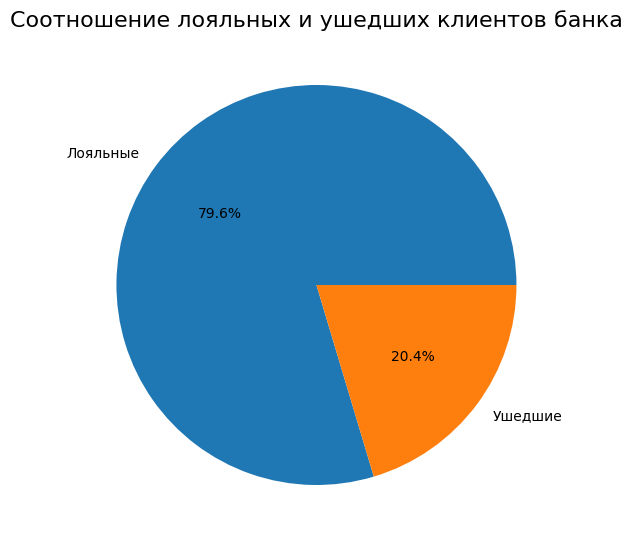

In [18]:
# Находим соотношение ушедших и лояльных клиентов
exits_count = churn_data['Exited'].value_counts()

# Строим круговую диаграмму
fig = plt.figure(figsize=(5,5))
axes = fig.add_axes([0, 0, 1, 1])
axes.set_title('Соотношение лояльных и ушедших клиентов банка', fontsize=16)
axes.pie(
    exits_count,
    autopct='%.1f%%',
    labels=['Лояльные', 'Ушедшие'],
);

Вывод по данной диаграмме: количество лояльных клиентов почти в четыре раза превышает количество ушедших клиентов, однако потеря порядка 20% своей клиентской базы — это достаточно серьезно, и является весомым основанием для контроля и улучшения качества.

# Задание 9.2

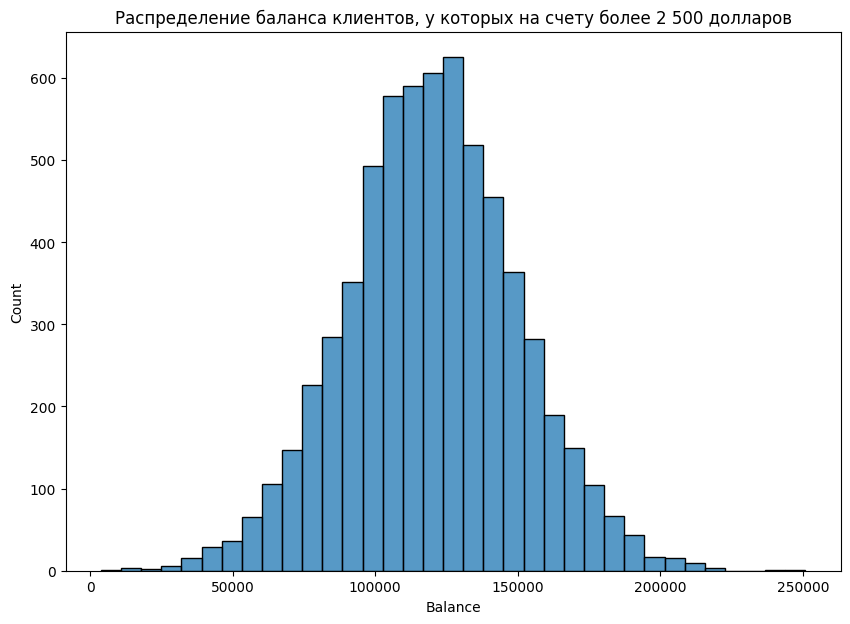

In [27]:
# Делаем фильтрацию по пользователям, у которых на счету больше 2 500 долларов
balance_mask = churn_data[churn_data['Balance'] > 2500]

# Создаем график
hist_fig = plt.figure(figsize=(10, 7))
balance_hist = sns.histplot(
    data=balance_mask,
    x='Balance',
    bins=35
)
balance_hist.set_title('Распределение баланса клиентов, у которых на счету более 2 500 долларов');


Выводы:

* В целом распределение достаточно равномерное;

* У большинства клиентов банка баланс примерно от 90 000 до 160 000 долларов;

* У банка есть клиенты с балансом более 250 000 долларов, но их крайне мало;

* Пиковые значения баланса находятся в диапазоне от 110 000 до 130 000 долларов;

* Наибольший интерес для банка представляют клиенты с балансом в диапазоне 100 000 - 140 000 долларов.

# Задание 9.3

/var/folders/q9/0s7pgp0s1bs8kcd4zcymcv940000gn/T/ipykernel_10877/1791911101.py:8: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



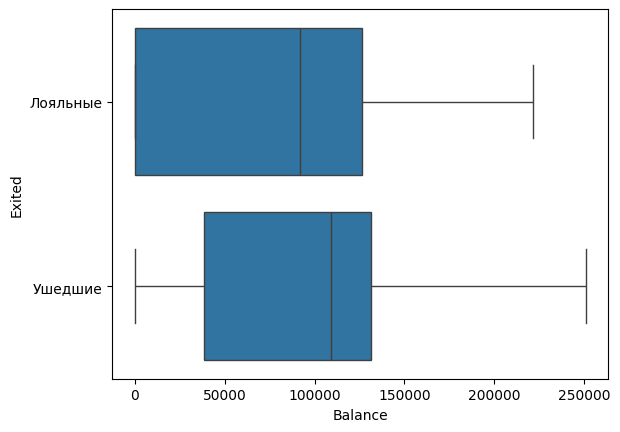

In [ ]:
# Строим коробочную диаграмму для определения разницы 
# распределений баланса в разрезе оттока клиентов
box_fig = sns.boxplot(
    data=churn_data,
    y='Exited',
    x='Balance',
    orient='h'
)
box_fig.set_yticklabels(('Лояльные', 'Ушедшие'));

* Средний баланс ушедших клиентов выше (в районе 110000 долларов). У лояльных клиентов средний баланс ниже (около 90000 долларов);
* Судя по ящику на верхней диаграмме, среди лояльных клиентов много тех, чей баланс либо низкий, либо равен нулю;
* Межквартильный размах на нижней диаграмме проходит в диапазоне 40 000 - 140 000, а на верхней — в диапазоне 0 - 120 000. То есть у лояльных клиентов распределение балансов более широкое;
* Максимальные балансы у обеих групп клиентов похожи, но плотность значений выше у ушедших;
* Исходя из графика, можно сделать вывод, что уходят люди, у которых на счетах есть значительные суммы, то есть чем выше баланс, тем выше вероятность оттока. Если посмотреть на коробчатые диаграммы вместе с гистограммой, то можно заметить, что уходят клиенты из числа тех, которые представляют наибольший интерес для банка. Вероятно, людей, у которых есть деньги, не устраивают условия вкладов, продукты банка, или качество обслуживания. 

# Задание 9.4

/var/folders/q9/0s7pgp0s1bs8kcd4zcymcv940000gn/T/ipykernel_10877/3129614430.py:9: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



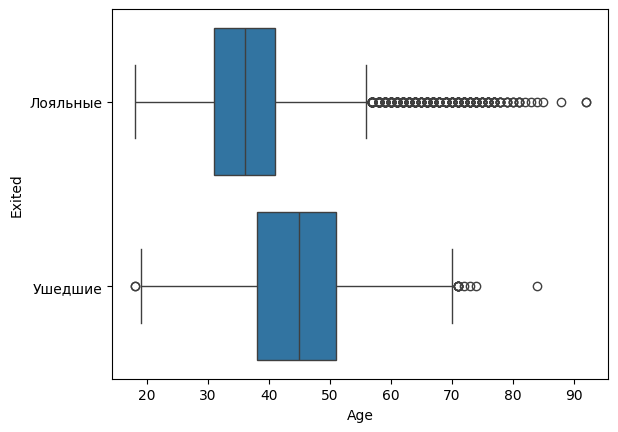

In [44]:
# Строим коробочную диаграмму для определения разницы 
# распределений возраста в разрезе оттока клиентов
box_fig = sns.boxplot(
    data=churn_data,
    y='Exited',
    x='Age',
    orient='h'
)
box_fig.set_yticklabels(('Лояльные', 'Ушедшие'));

* У лояльных клиентов выбросов сильно больше, и все они в стороне старших возрастов;
* Медиана на нижней диаграмме находится в районе 45 лет, а на верхней — в районе 36 лет. Это говорит о том, что ушедшие клиенты в среднем старше, в то время как лояльные клиенты обычно более молодого возраста;
* Основная масса ушедших сосредоточена в диапазоне примерно 38 - 51 года, а лояльных — в диапазоне 30 - 42 лет. Из этого следует, что банку стоит обратить внимание на клиентов в возрасте 40 - 50 лет.

# Задание 9.5

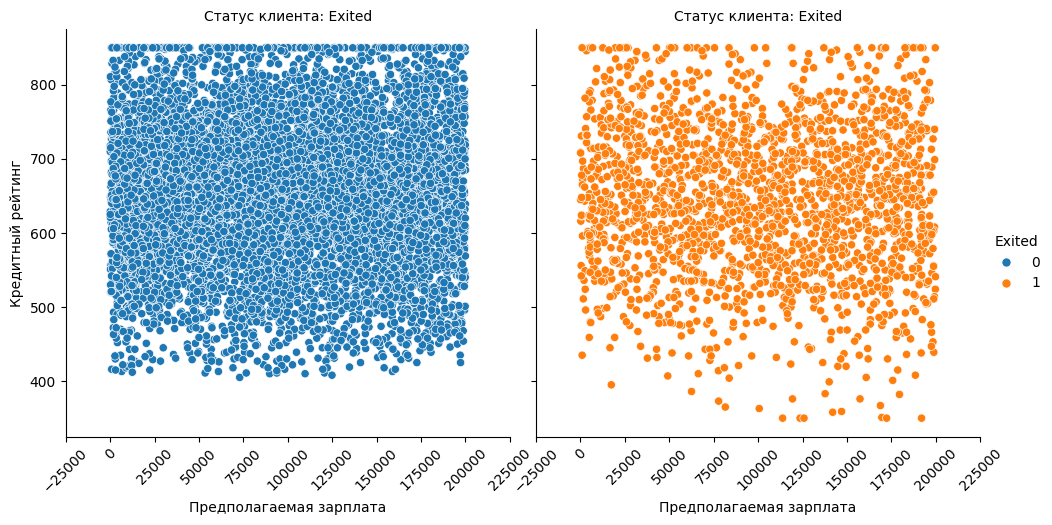

In [60]:
# Построим диаграмму рассеяния, чтобы отследить взаимосвязь кредитного рейтинга
# и предполагаемой зарплаты
scatter = sns.relplot(
    data=churn_data,
    x='EstimatedSalary',
    y='CreditScore',
    hue='Exited',
    col='Exited',
    kind='scatter',
)

scatter.set_axis_labels('Предполагаемая зарплата', 'Кредитный рейтинг')
scatter.set_titles('Статус клиента: {}'.format('Exited'))
scatter.set_xticklabels(rotation=45);

* Зарплаты распределены в диапазоне от 0 до 200 000 долларов, а кредитный рейтинг — от примерно 300 до 850, и ушедшие клиенты есть во всех диапазонах;
* Среди лояльных и ушедших клиентов есть люди с любыми комбинациями зарплат и кредитных рейтингов;
* Плотность точек на графиках для лояльных и ушедших клиентов различается не очень сильно. Это говорит о том, что зарплата и кредитный рейтинг не отличают лояльных клиентов от ушедших;
* На графике видно, что точки распределены достаточно равномерно. Это может значить, что прямой зависимости между зарплатой и кредитным рейтингом нет.



# Задание 9.6

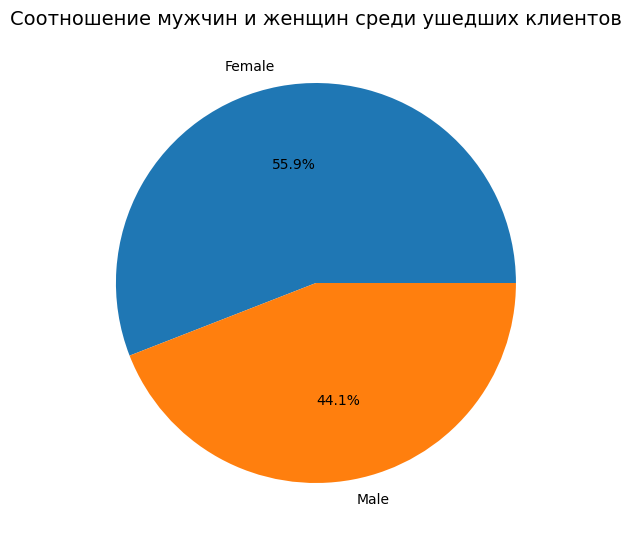

In [66]:
# Находим соотношение мужчин и женщин среди ушедших клиентов
exited_mask = churn_data[churn_data['Exited'] == 1]
gender_count = exited_mask['Gender'].value_counts()

# Строим круговую диаграмму
fig = plt.figure(figsize=(5,5))
axes = fig.add_axes([0, 0, 1, 1])
axes.set_title('Соотношение мужчин и женщин среди ушедших клиентов', fontsize=14)
axes.pie(
    gender_count,
    autopct='%.1f%%',
    labels=gender_count.index
);

На диаграмме видно, что женщины уходят чаще мужчин. Разница составляет примерно 12%.

# Задание 9.7

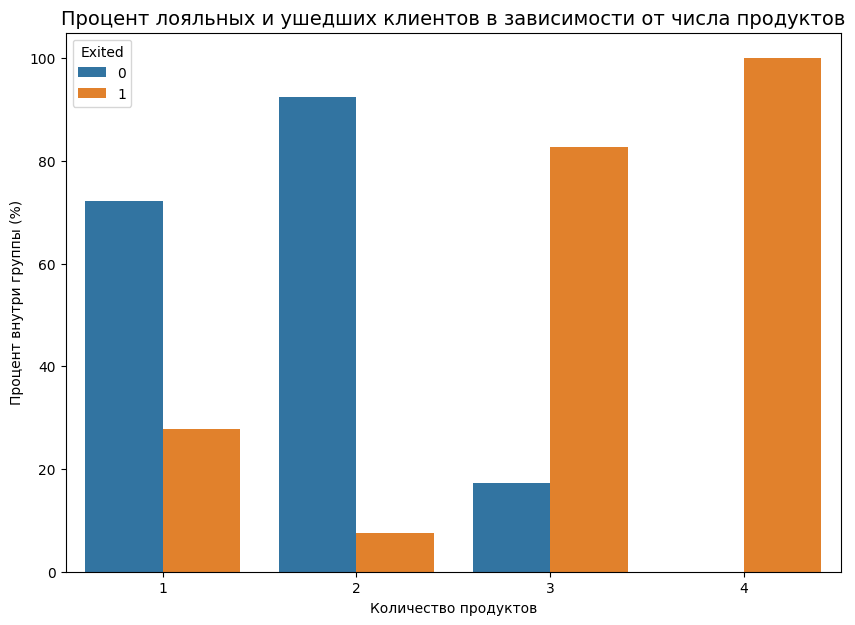

In [ ]:
# Группируем по продуктам и статусу, находим доли
product_churn_percent = (churn_data.groupby('NumOfProducts')['Exited'].value_counts(normalize=True).rename('Percentage').reset_index())

# Переводим доли в проценты для удобства восприятия
product_churn_percent['Percentage'] *= 100

# Строим график
fig = plt.figure(figsize=(10, 7))
barplot = sns.barplot(
    data=product_churn_percent,
    x='NumOfProducts',
    y='Percentage',
    hue='Exited'
)

plt.title('Процент лояльных и ушедших клиентов в зависимости от числа продуктов', fontsize=14)
plt.ylabel('Процент внутри группы (%)')
plt.xlabel('Количество продуктов')
plt.show()

* Более 80% клиентов, которые приобрели 3 продукта, уходят от банка;
* Клиенты, у которых 4 продукта, ушли практически все;
* Самый низкий уровень уходящих клиентов наблюдается на 2 продуктах;
* У клиентов с одним продуктов уровень оттока в несколько раз выше, чем у клиентов с двумя.

# Задание 9.8

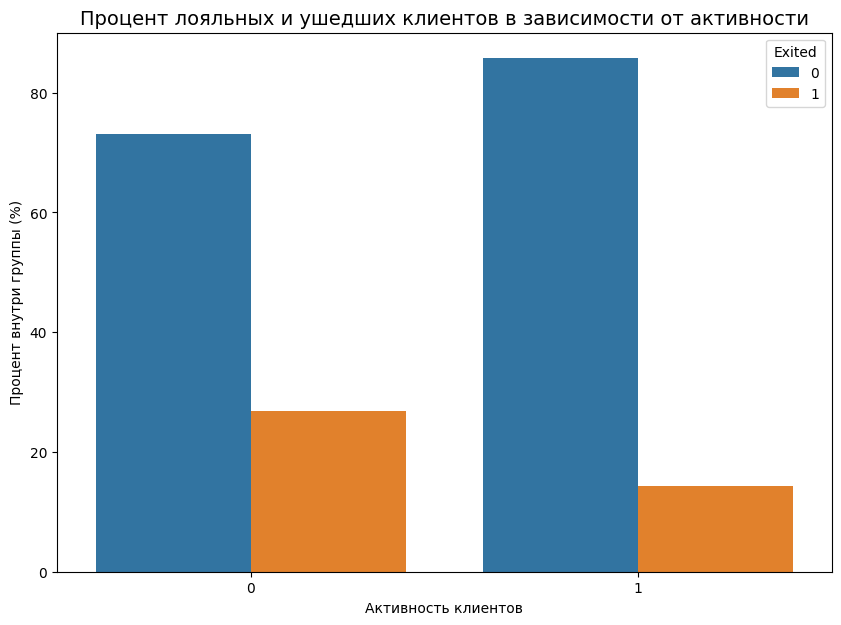

In [88]:
# Группируем по активности и статусу, находим доли
membership_churn_percent = (churn_data.groupby('IsActiveMember')['Exited'].value_counts(normalize=True).rename('Percentage').reset_index())

# Переводим доли в проценты для удобства восприятия
membership_churn_percent['Percentage'] *= 100

# Строим график
fig = plt.figure(figsize=(10, 7))
barplot = sns.barplot(
    data=membership_churn_percent,
    x='IsActiveMember',
    y='Percentage',
    hue='Exited'
)

plt.title('Процент лояльных и ушедших клиентов в зависимости от активности', fontsize=14)
plt.ylabel('Процент внутри группы (%)')
plt.xlabel('Активность клиентов')
plt.show()

По графику видно, что отток напрямую зависит от активности клиентов: процент оттока среди неактивных клиентов лежит в районе 30%, в то время как отток активных клиентов вдвое меньше.

Банку можно порекомендовать увеличить вовлеченность неактивной группы клиентов: возможно, какими-либо акциями, специальными предложениями, льготными условиями. В общем, важно мотивировать клиентов использовать счет чаще.

# Задание 9.9

In [98]:
# Фильтруем ушедших клиентов и делаем группировку по странам
churn_by_exited = churn_data[churn_data['Exited'] == 1]
churn_by_countries = churn_by_exited.groupby(by='Geography')['Exited'].count().reset_index()

# Строим тепловую картограмму
choro_fig = px.choropleth(
    data_frame=churn_by_countries,
    locations='Geography',
    locationmode='country names',
    color='Exited',
    title='Отток клиентов по странам',
    width=800,
    height=500,
    color_continuous_scale='Reds'
)

choro_fig.show();

/var/folders/q9/0s7pgp0s1bs8kcd4zcymcv940000gn/T/ipykernel_10877/1274533830.py:6: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



Наибольшее число ушедших клиентов фиксируется в Германии и Франции — в этих странах число ушедших практически идентичное. В Испании количество ушедших клиентов почти вдвое меньше. На карте видно, что цветом выделены только эти три страны — потому, что данный банк представлен только в них.

# Задание 9.10

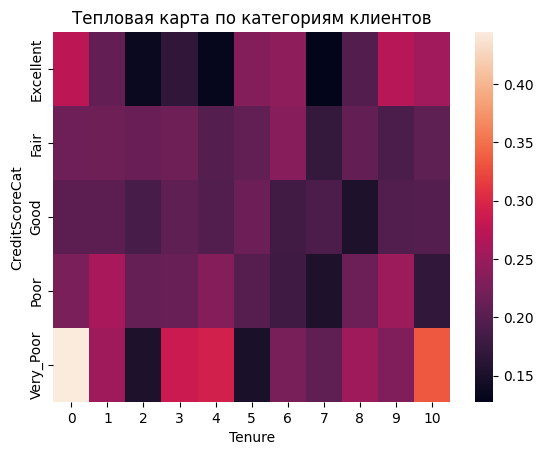

In [ ]:
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

# Применяем функцию к столбцу и создаем новый признак, после чего строим
# сводную таблицу
churn_data['CreditScoreCat'] = churn_data['CreditScore'].apply(get_credit_score_cat)
churn_pivot = churn_data.pivot_table(
    columns='Tenure',
    values='Exited',
    index='CreditScoreCat',
    aggfunc="mean"
)

# Создаем тепловую карту
heatmap = sns.heatmap(data=churn_pivot)
heatmap.set_title('Тепловая карта по категориям клиентов');

* На тепловой карте видно, что чаще всего уходят новые клиенты с минимальным кредитным рейтингом (Tenure = 0, CreditScoreCat = Very_Poor);
* Также видно рост оттока у клиентов с очень низким кредитным рейтингом на сроке 10 лет;
* Категория Very_Poor имеет больше светлых зон по сравнению с остальными. На основе этого можно сделать вывод, что клиенты с очень низким рейтингом менее лояльны, и их лояльность не зависит от количества лет, проведенных с этим банком;
* В интервале 2-4 и 6-8 лет фиксируется наименьший отток.